# Analyzing LLM Annotation Consensus

This notebook aggregates and visualizes the results of our automated LLM-based cognitive ontology annotation. We parse the JSON outputs from the 100 independent iterations generated in the previous step.

By mapping the anonymized labels (`Cluster 1`, `Cluster 2`, `Cluster 3`) back to their respective theoretical motifs, we can quantify the frequency of specific domain names proposed by the model. This allows us to establish a mathematically robust consensus on the macroscopic functional identity of each VMPFC subregion.

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import httpx
import json
import joblib
import numpy as np
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams['axes.grid'] = False
plt.rcParams['font.sans-serif'] = ['Arial']

DATA_PATH = Path('../data')
RESULTS_PATH = Path('../results')
PLOTS_PATH = Path('../plots')
DOCUMENTS_PATH = Path('../documents')
PLOT_KWARGS_DICT = dict(dpi=300, transparent=True, bbox_inches='tight')
CLUSTER_MAP_MOTIF_NAME_DICT = {
    'Cluster 1': 'affect',
    'Cluster 2': 'valuation',
    'Cluster 3': 'social'
}

In [38]:
data_list = []
for file in (DATA_PATH / 'responses_15_gemini').iterdir():

    if file.suffix != ".json":
        continue
    with open(file, 'r', encoding='utf-8') as f:
        result_dict = json.load(f)
        data_list.extend(result_dict['clusters'])

data_df_15 = pd.DataFrame(data_list)
data_df_15['cluster_id'] = data_df_15['cluster_id'].map(CLUSTER_MAP_MOTIF_NAME_DICT)
print('length of term 15 data:', len(data_df_15))

length of term 15 data: 294


# Consensus Visualization: Restricted Term Set (Top 15)

We first analyze the annotations generated from the core set of 15 cognitive terms. We aggregate the predicted `domain_name` frequencies for each cluster and plot them as donut charts.

The color palettes (Red, Gold, Blue) correspond to our established visual scheme. The adjacent legends display the specific functional names generated by the LLM alongside their relative consensus percentage across the 100 runs. A high percentage for a single term indicates strong algorithmic agreement on the underlying cognitive network.

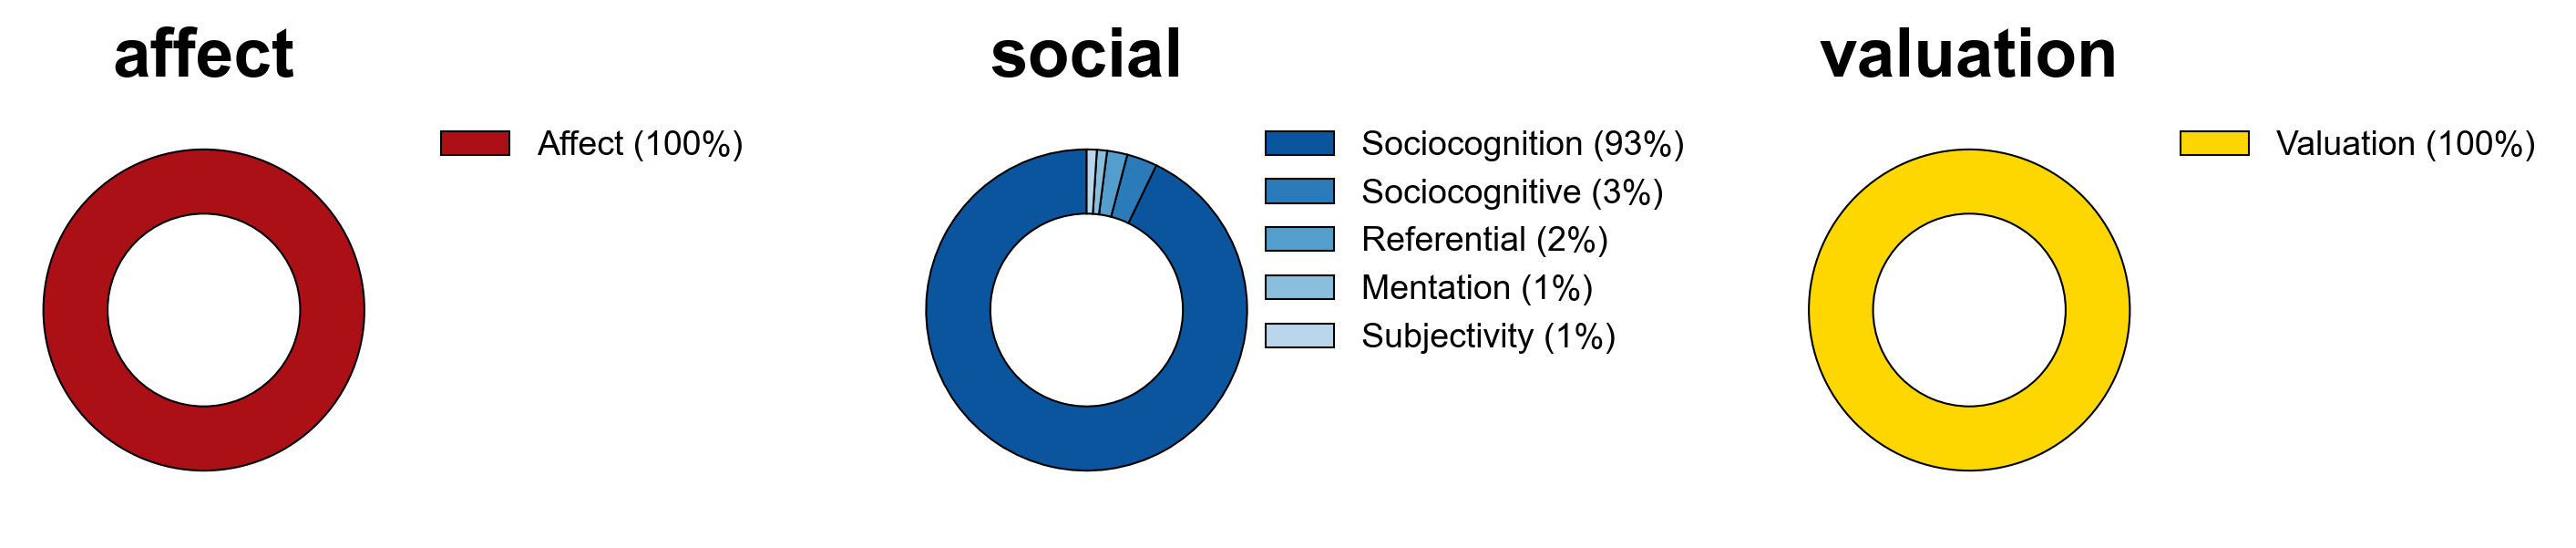

In [42]:
label_df_list = list(data_df_15.groupby('cluster_id')['domain_name'])
color_mapping_dict = {
  'affect': sns.color_palette('Reds_r'),
  'valuation': sns.light_palette("#FFD700", reverse=True, n_colors=3),
  'social': sns.color_palette('Blues_r'),

}

fig, axes = plt.subplots(1, 3, figsize=(10, 2), dpi=300)

for i, (name, label_df) in enumerate(label_df_list):
    ax = axes.flat[i]
    plot_data = label_df.value_counts()

    wedges, texts = ax.pie(
        plot_data.values,
        startangle=90,
        colors=color_mapping_dict[name],
        wedgeprops={'edgecolor': 'black', 'linewidth': 0.5, 'width': 0.4}  # Wider ring for readability
    )

    # Create legend labels with percentages (Format: Label (XX%))
    legend_labels = [f'{l} ({s/plot_data.sum()*100:1.0f}%)' for l, s in zip(plot_data.index, plot_data.values)]

    ax.legend(
        wedges,
        legend_labels,
        title='',
        loc="upper center",
        bbox_to_anchor=(1.6, 1),
        fontsize=9,
        frameon=False
    )


    ax.set_title(name,  weight='bold', fontsize=18)
    ax.axis('equal')

plt.subplots_adjust(wspace=1.5, hspace=0)
fig.savefig(PLOTS_PATH/'LLM_naming_15.svg', **PLOT_KWARGS_DICT)
fig.savefig(PLOTS_PATH/'LLM_naming_15.png', **PLOT_KWARGS_DICT)

# Consensus Visualization: Extended Term Set (Top 50)

To verify the stability of the model's neurocognitive judgments, we repeat the exact same aggregation and visualization process for the LLM annotations based on the extended dictionary of 50 cognitive terms.

Comparing the consensus distributions between the 15-term and 50-term sets provides critical evidence that the extracted functional domains are resilient to the specific granularity or breadth of the input vocabulary.

In [ ]:
data_list = []
for file in (DATA_PATH / 'responses_50_gemini').iterdir():
    if file.suffix != ".json":
        continue

    with open(file, 'r', encoding='utf-8') as f:
        result_dict = json.load(f)
        data_list.extend(result_dict['clusters'])

data_df_50 = pd.DataFrame(data_list)
data_df_50['cluster_id'] = data_df_50['cluster_id'].map(CLUSTER_MAP_MOTIF_NAME_DICT)
print('length of term 50 data:', len(data_df_50))

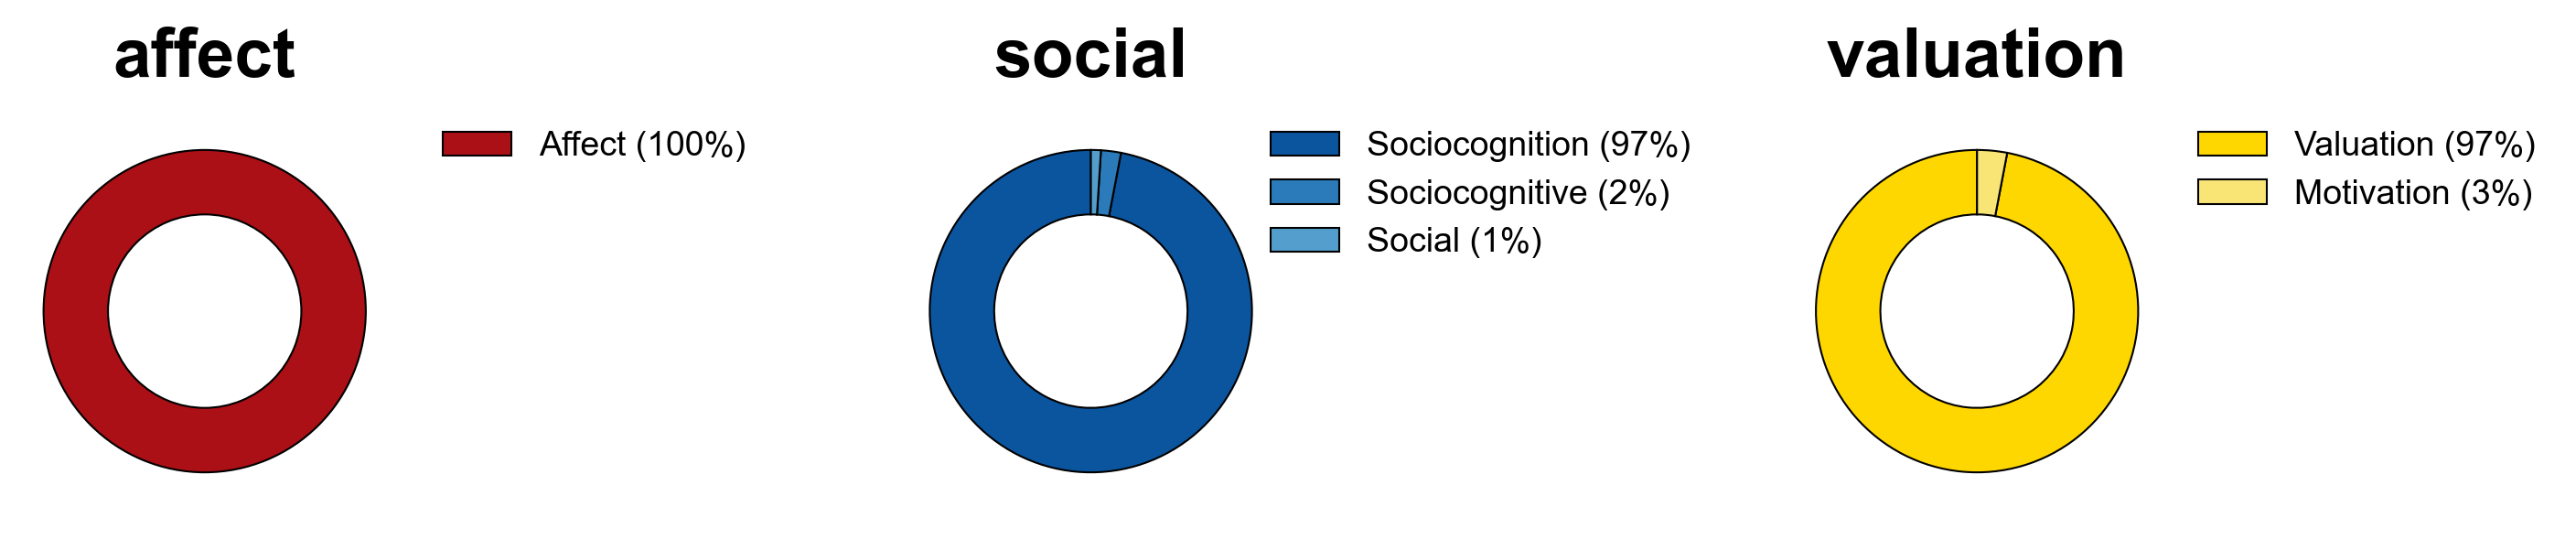

In [44]:
label_df_list = list(data_df_50.groupby('cluster_id')['domain_name'])

color_mapping_dict = {
    'affect': sns.color_palette('Reds_r'),
    'valuation': sns.light_palette("#FFD700", reverse=True, n_colors=3),
    'social': sns.color_palette('Blues_r'),
}

fig, axes = plt.subplots(1, 3, figsize=(10, 2), dpi=300)

for i, (name, label_df) in enumerate(label_df_list):
    ax = axes.flat[i]
    plot_data = label_df.value_counts()

    wedges, texts = ax.pie(
        plot_data.values,
        startangle=90,
        colors=color_mapping_dict[name],
        wedgeprops={'edgecolor': 'black', 'linewidth': 0.5, 'width': 0.4}
    )

    # Create legend labels with percentages (Format: Label (XX%))
    legend_labels = [f'{l} ({s/plot_data.sum()*100:1.0f}%)' for l, s in zip(plot_data.index, plot_data.values)]

    ax.legend(
        wedges,
        legend_labels,
        title='',
        loc="upper center",
        bbox_to_anchor=(1.6, 1),
        fontsize=9,
        frameon=False
    )

    ax.set_title(name, weight='bold', fontsize=18)
    ax.axis('equal')

plt.subplots_adjust(wspace=1.5, hspace=0)
fig.savefig(PLOTS_PATH / 'LLM_naming_50.svg', **PLOT_KWARGS_DICT)
fig.savefig(PLOTS_PATH / 'LLM_naming_50.png', **PLOT_KWARGS_DICT)